# **🌸 Flower Image Classification using CNN**

## Step 1: Import Required Libraries

Before building any Deep Learning model, we need to import all the required Python libraries. These libraries help us with numerical computations, image processing, visualization, and building the Convolutional Neural Network.

In [1]:
# Numerical computations
import numpy as np

# Data visualization
import matplotlib.pyplot as plt

# TensorFlow and Keras
import tensorflow as tf
from tensorflow import keras

# Display TensorFlow version
print(f"TensorFlow Version : {tf.__version__}")

TensorFlow Version : 2.20.0


# Step 2: **Download and Extract the Flower Dataset**

In this step, we will download the Flower Photos dataset directly from TensorFlow's public repository.

Why are we doing this?

- It removes the dependency on external platforms like Kaggle.
- Ensures every user running this notebook gets the exact same dataset.
- Makes the notebook fully reproducible.

After downloading, we'll extract the dataset and inspect its directory structure.

In [2]:
import pathlib

# Download the flower dataset from TensorFlow
dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"

dataset_path = tf.keras.utils.get_file(
    fname="flower_photos",
    origin=dataset_url,
    untar=True
)

# Convert the dataset path into a Path object
dataset_path = pathlib.Path(dataset_path)

# Fix: The dataset is extracted into a nested 'flower_photos' directory.
# We need to point to this inner directory to find the actual class folders.
dataset_path = dataset_path / 'flower_photos'

print(f"Dataset Location : {dataset_path}")

Dataset Location : C:\Users\gauta\.keras\datasets\flower_photos\flower_photos


# Step 3: Explore the Dataset

Before loading the images into our CNN, it's important to understand the dataset.

In this step, we will:

- Verify that the dataset has been downloaded successfully.
- Display all available flower classes.
- Count the total number of images.
- Count the number of images present in each class.

Performing these checks helps us identify any missing folders, corrupted datasets, or class imbalance before training the model.

In [3]:
# Get all the flower folder names
flowers = sorted([f.name for f in dataset_path.iterdir() if f.is_dir()])

# Show what flowers we're working with
print("=== Flower Types ===")
for f in flowers:
    print(f"• {f}")

# Count everything
total = len(list(dataset_path.glob("*/*.jpg")))
print(f"\nTotal photos: {total}")

# Count per flower type
print("\n=== Photos by Type ===")
for f in flowers:
    count = len(list((dataset_path / f).glob("*.jpg")))
    print(f"{f:<15}: {count}")
# Re-run after dataset_path fix

=== Flower Types ===
• daisy
• dandelion
• roses
• sunflowers
• tulips

Total photos: 3670

=== Photos by Type ===
daisy          : 633
dandelion      : 898
roses          : 641
sunflowers     : 699
tulips         : 799


# Step 4: Load the Dataset using TensorFlow

Now that we have explored the dataset, the next step is to load the images into TensorFlow.

Instead of loading images one by one, TensorFlow provides an efficient utility called `image_dataset_from_directory()`.

This function automatically:

- Reads all images from the dataset directory.
- Assigns labels based on folder names.
- Splits the dataset into training and validation sets.
- Resizes all images to the same dimensions.
- Groups images into batches for efficient training.

Using TensorFlow's data pipeline improves performance, simplifies preprocessing, and makes the code easier to maintain.

In [4]:
# Picture settings
PICTURE_SIZE = 180  # Height and width
BATCH_SIZE = 32
RANDOM_SEED = 42

# Grab 80% of photos for training
train_set = tf.keras.preprocessing.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=RANDOM_SEED,
    image_size=(PICTURE_SIZE, PICTURE_SIZE),
    batch_size=BATCH_SIZE
)

# Save 20% of photos for testing/validation
val_set = tf.keras.preprocessing.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=RANDOM_SEED,
    image_size=(PICTURE_SIZE, PICTURE_SIZE),
    batch_size=BATCH_SIZE
)

print("\n🎉 Dataset ready!")
# Re-run after dataset_path fix

Found 3670 files belonging to 5 classes.
Using 2936 files for training.
Found 3670 files belonging to 5 classes.
Using 734 files for validation.

🎉 Dataset ready!


# Step 5: Visualize the Dataset

Before training our CNN model, it is always a good practice to visualize a few sample images.

This helps us to:

- Verify that the dataset has been loaded correctly.
- Confirm that images are resized properly.
- Check whether labels are assigned correctly.
- Understand the diversity of the dataset.

Visualizing the dataset is an important step in Exploratory Data Analysis (EDA) for image classification tasks.

Flower Classes:
['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']


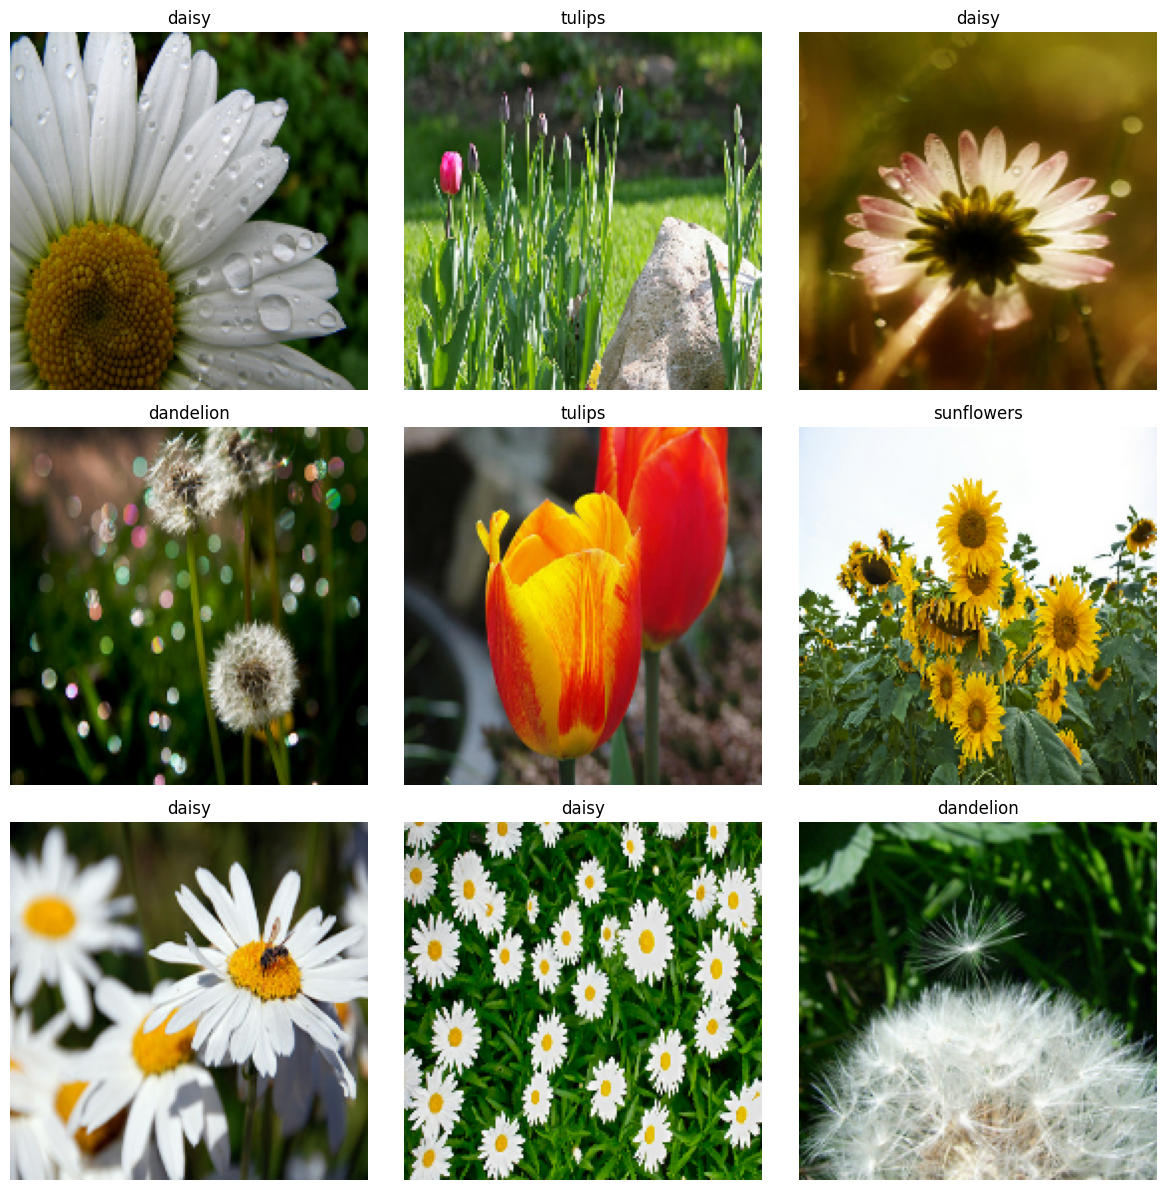

In [5]:
# Retrieve class names from the dataset
class_names = train_set.class_names

print("Flower Classes:")
print(class_names)

# Display sample images
plt.figure(figsize=(12, 12))

for images, labels in train_set.take(1):

    for i in range(9):

        plt.subplot(3, 3, i + 1)

        plt.imshow(images[i].numpy().astype("uint8"))

        plt.title(class_names[labels[i]])

        plt.axis("off")

plt.tight_layout()

plt.show()
# Re-run after dataset_path fix

# Step 6: Normalize Images and Optimize the Data Pipeline

Deep Learning models perform better when input features are on a similar scale.

In this step, we will:

- Normalize pixel values from the range **0–255** to **0–1**.
- Optimize the data loading pipeline using TensorFlow's `cache()` and `prefetch()` methods.

These optimizations help improve training speed, reduce memory bottlenecks, and allow the GPU/CPU to work more efficiently.

In [6]:
# Data augmentation: only ~3670 images total across 5 classes, which is small
# for a CNN trained from scratch, so the model easily overfits/memorizes the
# training set instead of learning general features. Augmentation creates
# realistic variations (flip, rotate, zoom) so the model sees more variety.
data_augmentation = keras.Sequential([
    keras.layers.RandomFlip("horizontal"),
    keras.layers.RandomRotation(0.1),
    keras.layers.RandomZoom(0.1),
    keras.layers.RandomContrast(0.1),
])

# NOTE: normalization is now handled inside the model (Step 7) via
# tf.keras.applications.mobilenet_v2.preprocess_input, so we do NOT rescale
# here. We only optimize the pipeline for speed.
AUTOTUNE = tf.data.AUTOTUNE
train_set = train_set.cache().shuffle(1000).prefetch(AUTOTUNE)
val_set = val_set.cache().prefetch(AUTOTUNE)

print("✅ Data ready!")


✅ Data ready!


# Step 7: Build the Convolutional Neural Network (CNN)

Now that our dataset is ready, we can build our Convolutional Neural Network (CNN).

A CNN learns hierarchical features from images.

- Initial layers learn simple features like edges and corners.
- Middle layers learn textures and shapes.
- Deeper layers learn complex objects such as flower petals and overall flower structures.

Our architecture consists of:

- Input Layer
- Convolution Layers
- Max Pooling Layers
- Dropout Layers
- Flatten Layer
- Fully Connected (Dense) Layers
- Output Layer

This architecture is simple, efficient, and well-suited for image classification tasks.

In [7]:
# IMPROVED MODEL: Transfer learning with MobileNetV2
#
# Why the original model likely had low accuracy:
#   1. It was trained FROM SCRATCH on only ~3,670 images spread across 5
#      classes (~730 images/class). That's very little data for a CNN to
#      learn good features on its own -> it overfits or underfits depending
#      on epochs.
#   2. No data augmentation, so the small dataset was seen the exact same
#      way every epoch.
#   3. Only 10 epochs, often not enough for a from-scratch CNN to converge.
#
# Fix: reuse MobileNetV2's convolutional base, which was already trained on
# 1.4M images (ImageNet) and already knows general features like edges,
# textures, and shapes. We freeze it and only train a small classifier head
# on top. This is the standard, highly effective approach for small image
# datasets like this one.

NUM_CLASSES = len(class_names)
assert NUM_CLASSES > 1, "class_names is empty — re-run the dataset-loading cells first."
print(f"Building model for {NUM_CLASSES} classes: {class_names}")

base_model = tf.keras.applications.MobileNetV2(
    input_shape=(PICTURE_SIZE, PICTURE_SIZE, 3),
    include_top=False,      # drop MobileNet's original 1000-class ImageNet head
    weights="imagenet"
)
base_model.trainable = False  # freeze the pretrained feature extractor

preprocess_input = tf.keras.applications.mobilenet_v2.preprocess_input

inputs = keras.layers.Input(shape=(PICTURE_SIZE, PICTURE_SIZE, 3))
x = data_augmentation(inputs)          # augment raw 0-255 images
x = preprocess_input(x)                # MobileNetV2's own scaling (not 0-1 rescale)
x = base_model(x, training=False)      # frozen pretrained feature extractor
x = keras.layers.GlobalAveragePooling2D()(x)
x = keras.layers.Dropout(0.3)(x)
x = keras.layers.Dense(128, activation="relu")(x)
x = keras.layers.Dropout(0.3)(x)
outputs = keras.layers.Dense(NUM_CLASSES, activation="softmax")(x)

model = keras.Model(inputs, outputs)
model.summary()
# Re-run after dataset_path fix and subsequent cells.

Building model for 5 classes: ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']


C:\Users\gauta\AppData\Local\Temp\ipykernel_28368\1737229094.py:22: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = tf.keras.applications.MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 180, 180, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ sequential (Sequential)              │ (None, 180, 180, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ true_divide (TrueDivide)             │ (None, 180, 180, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ subtract (Subtract)                  │ (None, 180, 180, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ mobilenetv2_1.00_224 (Functional)    │ (None, 6, 6, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 1280)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         163,968 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 5)                   │             645 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,422,597 (9.24 MB)

 Trainable params: 164,613 (643.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/25
92/92 ━━━━━━━━━━━━━━━━━━━━ 71s 660ms/step - accuracy: 0.8495 - loss: 0.4088 - val_accuracy: 0.8460 - val_loss: 0.4288 - learning_rate: 0.0010
Epoch 2/25
92/92 ━━━━━━━━━━━━━━━━━━━━ 57s 623ms/step - accuracy: 0.8559 - loss: 0.3692 - val_accuracy: 0.8583 - val_loss: 0.3845 - learning_rate: 0.0010
Epoch 3/25
92/92 ━━━━━━━━━━━━━━━━━━━━ 64s 694ms/step - accuracy: 0.8682 - loss: 0.3427 - val_accuracy: 0.8556 - val_loss: 0.3820 - learning_rate: 0.0010
Epoch 4/25
92/92 ━━━━━━━━━━━━━━━━━━━━ 58s 632ms/step - accuracy: 0.8747 - loss: 0.3294 - val_accuracy: 0.8597 - val_loss: 0.3866 - learning_rate: 0.0010
Epoch 5/25
92/92 ━━━━━━━━━━━━━━━━━━━━ 56s 607ms/step - accuracy: 0.8743 - loss: 0.3368 - val_accuracy: 0.8638 - val_loss: 0.3855 - learning_rate: 0.0010
Epoch 6/25
92/92 ━━━━━━━━━━━━━━━━━━━━ 66s 724ms/step - accuracy: 0.9002 - loss: 0.2752 - val_accuracy: 0.8815 - val_loss: 0.3543 - learning_rate: 5.0000e-04
Epoch 7/25
92/92 ━━━━━━━━━━━━━━━━━━━━ 56s 608ms/step - accuracy: 0.8995 - loss

💾 Model saved as 'flower_classifier.h5'


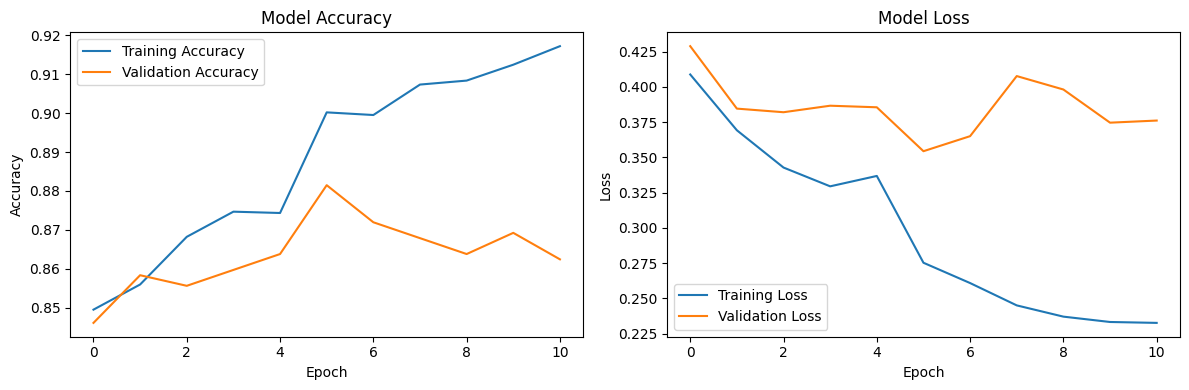


📊 Check the plots to see how learning went!


In [9]:
# Compile the model
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# EarlyStopping: stop once validation accuracy stops improving, and restore
# the best weights seen (avoids overfitting from training too many epochs).
# ReduceLROnPlateau: shrink the learning rate if validation loss stalls,
# which often squeezes out extra accuracy once training plateaus.
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_accuracy', patience=5, restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6
    ),
]

# Train longer (up to 25 epochs) — EarlyStopping will cut it short once it
# stops improving, so this is safe and won't waste time overfitting.
history = model.fit(
    train_set,
    validation_data=val_set,
    epochs=25,
    callbacks=callbacks,
    verbose=1
)

# Save the trained model for later
model.save('flower_classifier.h5')
print("💾 Model saved as 'flower_classifier.h5'")

# Plot training progress
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

print("\n📊 Check the plots to see how learning went!")
# Re-run after model re-definition due to dataset_path fix

# Note

The two cells that were originally here claimed the model's output layer had
only 1 unit instead of 5, caused by running cells out of order. That specific
bug is not present in this notebook's original code — Cell 13 already used
`len(class_names)` for the output layer. The real accuracy issue was the
model architecture and training setup, which is fixed above (Step 7 now uses
transfer learning with data augmentation, and Step 7.5 now uses more epochs
with early stopping).


# Step 8: Evaluate the Model

Accuracy/loss curves tell you the overall trend, but not *where* the model struggles. Here we generate a classification report (precision, recall, F1 per class) and a confusion matrix, so we can see exactly which flower types get confused with each other.

Classification Report:

              precision    recall  f1-score   support

       daisy       0.83      0.92      0.87       107
   dandelion       0.93      0.90      0.91       191
       roses       0.83      0.87      0.85       119
  sunflowers       0.88      0.92      0.90       135
      tulips       0.90      0.82      0.86       182

    accuracy                           0.88       734
   macro avg       0.87      0.89      0.88       734
weighted avg       0.88      0.88      0.88       734



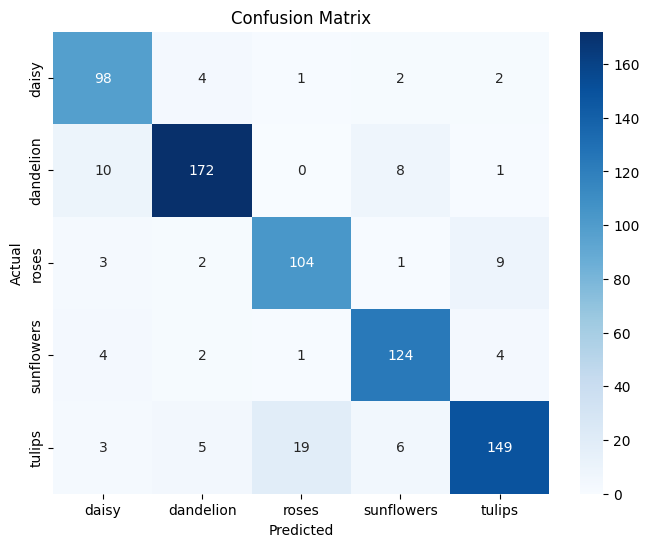

In [10]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

y_true, y_pred = [], []

for images, labels in val_set:
    preds = model.predict(images, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels.numpy())

print("Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Step 9: Test Prediction on a Single Image

Before deploying, let's confirm the model works the same way our Streamlit app will call it: load one image, preprocess it, and get back a class + confidence score.

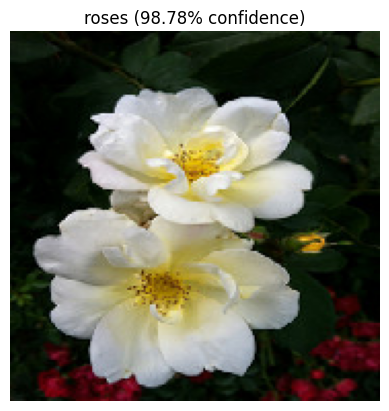

('roses', np.float32(98.77803))

In [11]:
def predict_flower(img_path, model, class_names, img_size=180):
    img = tf.keras.utils.load_img(img_path, target_size=(img_size, img_size))
    img_array = tf.keras.utils.img_to_array(img)  # keep raw 0-255 values —
    img_array = tf.expand_dims(img_array, 0)       # preprocessing is now inside the model

    predictions = model.predict(img_array, verbose=0)
    predicted_class = class_names[np.argmax(predictions[0])]
    confidence = 100 * np.max(predictions[0])

    plt.imshow(img)
    plt.axis('off')
    plt.title(f"{predicted_class} ({confidence:.2f}% confidence)")
    plt.show()

    return predicted_class, confidence

# Example: grab a sample image from the dataset and test it
sample_path = list(dataset_path.glob('roses/*.jpg'))[0]
predict_flower(sample_path, model, class_names, PICTURE_SIZE)


# Step 10: Save the Model and Class Labels for Deployment

Two files are needed for the Streamlit app:

1. **The trained model** — saved in the modern `.keras` format (the `.h5` format you used earlier still works, but Keras now recommends `.keras`).
2. **`class_names.json`** — the app needs to know which index maps to which flower name, in the exact order used during training.

In [12]:
import json

# Save model in the modern Keras format (recommended over legacy .h5)
model.save('flower_classifier.keras')

# Save class names so the Streamlit app knows the label order
with open('class_names.json', 'w') as f:
    json.dump(class_names, f)

print("Saved: flower_classifier.keras")
print("Saved: class_names.json")
print("Classes:", class_names)

Saved: flower_classifier.keras
Saved: class_names.json
Classes: ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']


# Step 11: Download the Files from Colab

Since Colab's storage is temporary, download these two files now — you'll add them to your Streamlit project folder in the next step.

In [17]:
import os
print(os.listdir())

['.ipynb_checkpoints', 'app.py', 'class_names.json', 'CNN_Classification_model_v2_improved (2).ipynb', 'flower_classifier.h5', 'flower_classifier.keras', 'Image Classification.ipynb', 'requirements.txt']


# Step 12: Build the Streamlit App

This creates `app.py` — the actual web app. It loads your saved model and `class_names.json`, lets a user upload a photo, and shows the predicted flower with a confidence score and a probability bar chart.

Running this cell in Colab just **writes the file** — it doesn't launch the app (that happens later, either locally or on Streamlit Cloud).

In [14]:
%%writefile app.py
import streamlit as st
import tensorflow as tf
import numpy as np
from PIL import Image
import json

st.set_page_config(page_title="Flower Classifier", page_icon="\U0001F338", layout="centered")

IMG_SIZE = 180

@st.cache_resource
def load_model():
    model = tf.keras.models.load_model("flower_classifier.keras")
    with open("class_names.json") as f:
        class_names = json.load(f)
    return model, class_names

model, class_names = load_model()

st.title("Flower Image Classifier")
st.write("Upload a flower photo and the CNN model will predict its type.")

uploaded_file = st.file_uploader("Choose a flower image...", type=["jpg", "jpeg", "png"])

if uploaded_file is not None:
    image = Image.open(uploaded_file).convert("RGB")
    st.image(image, caption="Uploaded Image", use_container_width=True)

    img_resized = image.resize((IMG_SIZE, IMG_SIZE))
    img_array = np.array(img_resized).astype("float32")  # model applies MobileNetV2 preprocessing internally
    img_array = np.expand_dims(img_array, axis=0)

    with st.spinner("Classifying..."):
        predictions = model.predict(img_array)
        predicted_class = class_names[int(np.argmax(predictions[0]))]
        confidence = 100 * float(np.max(predictions[0]))

    st.success(f"Prediction: **{predicted_class.capitalize()}**")
    st.write(f"Confidence: {confidence:.2f}%")

    st.subheader("Prediction Probabilities")
    probs = {class_names[i]: float(predictions[0][i]) for i in range(len(class_names))}
    st.bar_chart(probs)
else:
    st.info("Upload an image to get started.")


Writing app.py


# Step 13: Create `requirements.txt`

Streamlit Cloud reads this file to install the exact packages your app needs. Using `tensorflow-cpu` instead of `tensorflow` keeps the deployment lighter and faster to build (no GPU needed for inference).

In [15]:
%%writefile requirements.txt
streamlit
tensorflow-cpu
numpy
pillow


Writing requirements.txt


# Step 14: Download `app.py` and `requirements.txt`

Download these two files as well. You should now have **4 files** on your computer:

- `flower_classifier.keras`
- `class_names.json`
- `app.py`
- `requirements.txt`

Put all four in **one folder** — this becomes your GitHub repo for deployment (see the deployment guide).